In [1]:
import os
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

In [2]:
dataset_dir = "/kaggle/input/ct-images/CT"  # Inside are 'cancer' and 'normal' subfolders

print("Dataset directory exists:", os.path.isdir(dataset_dir))


Dataset directory exists: True


In [3]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [4]:
full_dataset = datasets.ImageFolder(root=dataset_dir, transform=val_test_transform)

# Print classes and dataset size
print("Classes:", full_dataset.classes)
print("Total images:", len(full_dataset))

Classes: ['cancer', 'normal']
Total images: 3000


In [5]:
train_size = int(0.7 * len(full_dataset))
val_size   = int(0.15 * len(full_dataset))
test_size  = len(full_dataset) - train_size - val_size

In [6]:
torch.manual_seed(42)

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])
train_dataset.dataset.transform = train_transform 

In [7]:
batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2)

print("DataLoaders created successfully!")
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")


DataLoaders created successfully!
Train samples: 2100, Val samples: 450, Test samples: 450


In [8]:
import torch.nn as nn
import torch

class ShallowCNNModel(nn.Module):
    def __init__(self, num_classes):
        super(ShallowCNNModel, self).__init__()
        
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),  # (B, 16, 224, 224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # (B, 16, 112, 112)

            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),  # (B, 32, 112, 112)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # (B, 32, 56, 56)

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # (B, 64, 56, 56)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # (B, 64, 28, 28)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # Flatten the tensor
        x = self.fc_layers(x)
        return x

# Define number of classes (6 diseases)
num_classes = 6

# Initialize the model
model = ShallowCNNModel(num_classes=num_classes)
print(model)


ShallowCNNModel(
  (conv_layers): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=50176, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=6, bias=True)
  )
)


In [9]:
import torch.optim as optim

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training parameters
num_epochs = 60
patience = 4  # Stop if no improvement after 4 epochs
best_val_acc = 0.0
epochs_no_improve = 0

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    # === Training ===
    model.train()
    total, correct, train_loss = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    print(f"Train Loss: {train_loss/total:.4f} | Train Acc: {train_acc:.2f}%")

    # === Validation ===
    model.eval()
    total, correct, val_loss = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    val_acc = 100 * correct / total
    print(f"Val Loss: {val_loss/total:.4f} | Val Acc: {val_acc:.2f}%")

    # === Early Stopping ===
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        print("Validation improved, saving model...")
        torch.save(model.state_dict(), "best_model.pt")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epochs.")

    if epochs_no_improve >= patience:
        print("Early stopping triggered!")
        break



Epoch 1/60
Train Loss: 0.5649 | Train Acc: 70.90%
Val Loss: 0.4244 | Val Acc: 82.67%
Validation improved, saving model...

Epoch 2/60
Train Loss: 0.3734 | Train Acc: 83.24%
Val Loss: 0.3202 | Val Acc: 85.56%
Validation improved, saving model...

Epoch 3/60
Train Loss: 0.3289 | Train Acc: 85.29%
Val Loss: 0.3141 | Val Acc: 84.67%
No improvement for 1 epochs.

Epoch 4/60
Train Loss: 0.2841 | Train Acc: 87.38%
Val Loss: 0.3218 | Val Acc: 84.89%
No improvement for 2 epochs.

Epoch 5/60
Train Loss: 0.2692 | Train Acc: 88.19%
Val Loss: 0.2751 | Val Acc: 89.56%
Validation improved, saving model...

Epoch 6/60
Train Loss: 0.2524 | Train Acc: 88.76%
Val Loss: 0.2716 | Val Acc: 88.00%
No improvement for 1 epochs.

Epoch 7/60
Train Loss: 0.2301 | Train Acc: 90.14%
Val Loss: 0.2429 | Val Acc: 88.67%
No improvement for 2 epochs.

Epoch 8/60
Train Loss: 0.2187 | Train Acc: 91.14%
Val Loss: 0.2147 | Val Acc: 90.89%
Validation improved, saving model...

Epoch 9/60
Train Loss: 0.2047 | Train Acc: 91.1

<ipython-input-10-029e4b7e05e8>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt"))


Test Loss: 0.1400 | Test Accuracy: 93.78%

Confusion Matrix:
 [[218   8]
 [ 20 204]]

Classification Report:
               precision    recall  f1-score   support

      cancer       0.92      0.96      0.94       226
      normal       0.96      0.91      0.94       224

    accuracy                           0.94       450
   macro avg       0.94      0.94      0.94       450
weighted avg       0.94      0.94      0.94       450



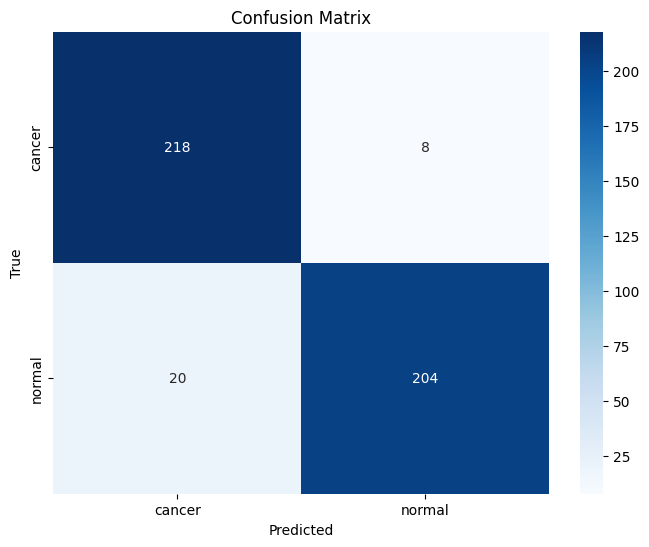

In [10]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Load best saved model
model.load_state_dict(torch.load("best_model.pt"))
model.to(device)
model.eval()

# Initialize accumulators
total, correct, test_loss = 0, 0, 0
all_labels, all_preds = [], []

# Evaluate on test set
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

# Compute overall test performance
test_loss /= total
test_acc = 100 * correct / total
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}%")

# Confusion Matrix & Classification Report
cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(all_labels, all_preds, 
      target_names=test_loader.dataset.dataset.classes))

# Visualize Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_loader.dataset.dataset.classes, 
            yticklabels=test_loader.dataset.dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
